In [26]:
%matplotlib inline

### 1. Library Imports

In this section, we import all necessary Python libraries for solving and visualizing a triangulation problem from the CG:SHOP 2025 challenge:

- `json`: for reading instance files formatted in JSON.
- `numpy`: for efficient numerical and array-based operations.
- `cgshop2025_pyutils`: a helper library provided by the challenge organizers for triangulation solving (`DelaunayBasedSolver`) and solution verification (`verify`).
- `matplotlib.pyplot`: for creating visualizations of the geometry and triangulation.
- `os`: for constructing file paths in a platform-independent way.
- `shapely.geometry.Polygon`: to perform geometric checks such as containment of points within polygons.
- `networkx`: for graph-based operations like finding cliques (triangles) in the triangulation.

These libraries enable us to process, solve, and analyze geometric instances effectively.

In [12]:
# Import required libraries
import json  # For handling JSON files
import numpy as np  # For numerical operations
from cgshop2025_pyutils import DelaunayBasedSolver, verify  # CG:SHOP challenge utilities
import matplotlib.pyplot as plt  # For visualization
import os  # For file path operations
from shapely.geometry import Polygon  # For geometric operations
import networkx as nx  # For graph operations

### 2. Data Loading and Preparation

In this section, we load the input JSON instance file containing the geometric data and prepare it in a structured format compatible with the triangulation solver.

- We define the instance filename and its directory, then build the full file path in a platform-independent way using `os.path.join`.
- Using the `json` library, we load the contents of the JSON file into a Python dictionary.
- A custom class `JsonInstance` is defined to encapsulate the instance data with convenient attributes:
  - Coordinates (`points_x` and `points_y`) are converted to NumPy arrays for efficient numerical operations.
  - The boundary indices of the region and any additional constraints are stored.
  - A unique identifier (`instance_uid`) for the instance is kept for reference.
- Finally, we create an object of `JsonInstance` that will be used by the solver in subsequent steps.

In [15]:
# Define the input file path
file_name = 'ortho_80_06ee55d4.instance.json'  # Instance filename
directory = 'challenge_instances_cgshop25'  # Directory containing instances
file_path = os.path.join(directory, file_name)  # Full file path

# Load the JSON data from the instance file
with open(file_path, "r") as file:
    data = json.load(file)

# Create a class to structure the instance data in a format compatible with the solver
class JsonInstance:
    def __init__(self, data):
        # Convert points to numpy arrays for efficient computation
        self.points_x = np.array(data["points_x"])  # X coordinates of points
        self.points_y = np.array(data["points_y"])  # Y coordinates of points
        self.region_boundary = data["region_boundary"]  # Indices of boundary points
        self.additional_constraints = data["additional_constraints"]  # Any additional constraints
        self.instance_uid = data["instance_uid"]  # Unique identifier for the instance

# Create an instance of our structured data
instance = JsonInstance(data)

### 3. Triangulation Solution

In this section, we initialize the Delaunay-based solver with our prepared instance and compute a triangulation solution.

- The `DelaunayBasedSolver` from `cgshop2025_pyutils` is initialized with the `instance` object.
- The `solve()` method computes the triangulation according to challenge specifications.
- The solution is then verified using the `verify` function to ensure it meets all challenge constraints.
- Any validation errors found in the solution are printed to the console.

In [16]:
# Initialize the Delaunay-based solver with our instance
solver = DelaunayBasedSolver(instance)

# Compute the triangulation solution
solution = solver.solve()

# Verify the solution meets all challenge requirements
result = verify(instance, solution)
print(f"Solution errors: {result.errors}")  # Print any validation errors

Solution errors: []


### 4. Visualization Preparation

This section prepares the data and configures the plot to visualize the triangulation solution clearly.

- The original points are combined into a NumPy array of `(x, y)` coordinates for easier handling.
- The polygon boundary is reconstructed by extracting boundary points from the instance and closing the polygon by repeating the first point.
- A `Polygon` object from Shapely is created for geometric containment checks.
- Matplotlib is configured to use a dark theme for better visual contrast.
- The boundary polygon is plotted with a thick white line.
- Original points are plotted with a distinct color (`lightsteelblue`).
- Finally, all edges of the computed triangulation solution are drawn in `steelblue`.


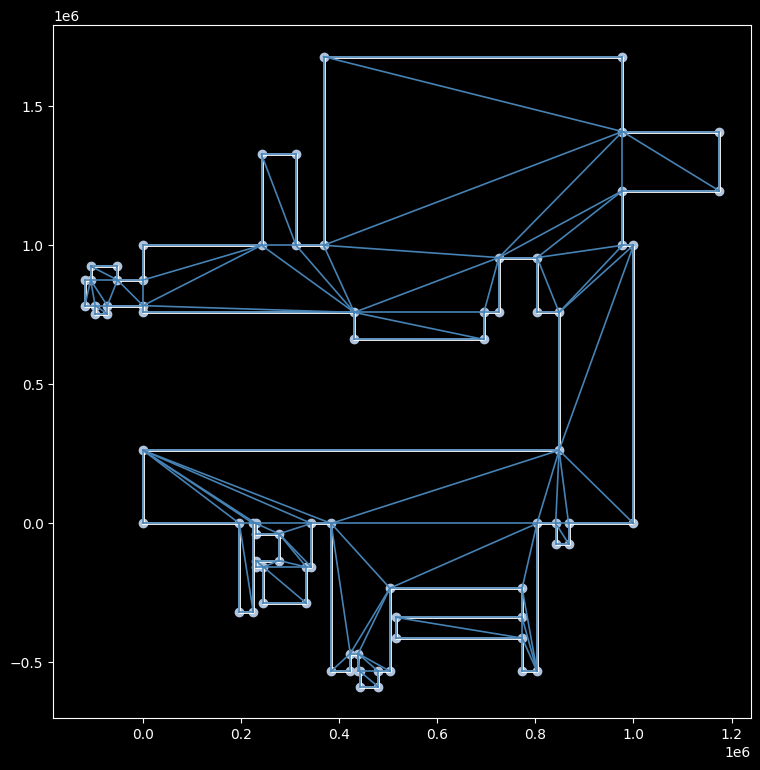

In [17]:
# Prepare point coordinates as numpy array for easier manipulation
points = np.array(list(zip(instance.points_x, instance.points_y)))

# Extract boundary points and close the polygon by repeating the first point
boundary = np.array([points[i] for i in instance.region_boundary])
boundary = np.append(boundary, [boundary[0]], axis=0)
boundary_polygon = Polygon(boundary)  # Create Shapely polygon for containment checks

# Configure visualization with dark theme
plt.style.use('dark_background')
plt.figure(figsize=(9, 9))  # Create a large square figure

# Plot the region boundary
plt.plot(boundary[:, 0], boundary[:, 1], 'white', linewidth=2, label='Boundary')

# Plot the original input points
plt.scatter(points[:, 0], points[:, 1], color='lightsteelblue', label='Original Points')

# Draw all edges from the computed triangulation
for edge in solution.edges:
    x_coords = [instance.points_x[edge[0]], instance.points_x[edge[1]]]
    y_coords = [instance.points_y[edge[0]], instance.points_y[edge[1]]]
    plt.plot(x_coords, y_coords, 'steelblue', linewidth=1.2)

### 5. Triangle Analysis - Part 1: Triangle Reconstruction and Incenter Calculation

In this part, we reconstruct all triangles from the triangulation edges using graph theory:

- We use NetworkX to create a graph from all edges.
- Enumerate all 3-cliques in the graph, which correspond to triangles.
- Define a function `calculate_incenter(triangle)` to compute the incenter (the center of the incircle) of a triangle using barycentric coordinates weighted by the edge lengths.

In [18]:
# Reconstruct all triangles from the edge list using graph theory
graph = nx.Graph()
graph.add_edges_from(solution.edges)
# Find all 3-cliques (triangles) in the graph
triangles = [c for c in nx.enumerate_all_cliques(graph) if len(c) == 3]

def calculate_incenter(triangle):
    """
    Calculate the incenter of a triangle (center point of incircle).
    Uses barycentric coordinates weighted by edge lengths.
    """
    # Calculate lengths of all three edges
    a = np.linalg.norm(triangle[1] - triangle[2])  # Edge opposite vertex 0
    b = np.linalg.norm(triangle[0] - triangle[2])  # Edge opposite vertex 1
    c = np.linalg.norm(triangle[0] - triangle[1])  # Edge opposite vertex 2
    
    perimeter = a + b + c
    # Compute incenter using barycentric coordinates
    incenter = (a * triangle[0] + b * triangle[1] + c * triangle[2]) / perimeter
    return incenter

### 5. Triangle Analysis - Part 2: Inradius and Tangency Points Calculation

Here we define two more functions for further geometric analysis:

- `calculate_inradius(triangle)` computes the radius of the incircle using Heron's formula.
- `calculate_tangency_points(triangle, incenter)` calculates the points where the incircle touches each edge by projecting the incenter orthogonally onto the edges.
- These calculations are fundamental to understand triangle properties and visualize the inner incircle and its tangency points.


In [19]:
def calculate_inradius(triangle):
    """
    Calculate the radius of the incircle using Heron's formula.
    """
    # Edge lengths
    a = np.linalg.norm(triangle[1] - triangle[2])
    b = np.linalg.norm(triangle[0] - triangle[2])
    c = np.linalg.norm(triangle[0] - triangle[1])
    
    # Semi-perimeter
    s = (a + b + c) / 2
    # Area using Heron's formula
    area = np.sqrt(s * (s - a) * (s - b) * (s - c))
    # Inradius formula
    inradius = area / s
    return inradius

def calculate_tangency_points(triangle, incenter):
    """
    Calculate points where the incircle touches each edge (tangency points).
    Uses orthogonal projection of the incenter onto each edge.
    """
    tangency_points = []
    for i in range(3):  # For each edge of the triangle
        p1 = triangle[i]  # First vertex of edge
        p2 = triangle[(i + 1) % 3]  # Second vertex of edge
        
        # Vector along the edge
        edge = p2 - p1
        edge_unit = edge / np.linalg.norm(edge)  # Unit vector
        
        # Project incenter onto the edge
        proj = np.dot(incenter - p1, edge_unit)
        # Calculate exact tangency point
        tangency_point = p1 + proj * edge_unit
        
        tangency_points.append(tangency_point)
    return tangency_points

### 5. Triangle Analysis - Part 3: Processing and Visualizing Triangles

This part processes each triangle found in the graph:

- For each triangle fully contained within the polygon boundary:
  - Compute the incenter and inradius.
  - Calculate tangency points where the incircle touches the edges.
  - Visualize the smaller “inner triangle” formed by these tangency points.
  - Store incenters and tangency points in dictionaries for further reference.
  - Map edges to their tangency points to help in later processing steps.


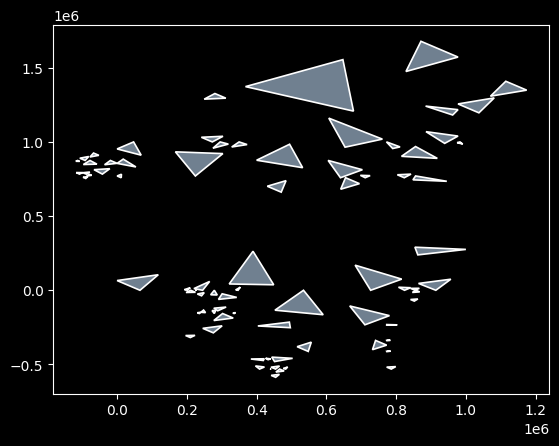

In [21]:
# Dictionaries to store geometric information
incenters = {}  # Maps triangles to their incenters
tangency_data = {}  # Maps triangles to their tangency points
edge_to_tangency = {}  # Maps edges to their adjacent triangles' tangency points

for triangle in triangles:
    # Get the actual points for this triangle
    tri_points = points[triangle]
    # Use sorted tuple as dictionary key for consistency
    sorted_triangle = tuple(sorted(triangle))
    
    # Only process triangles fully contained within the boundary
    if boundary_polygon.contains(Polygon(tri_points)):
        # Calculate geometric properties
        incenter = calculate_incenter(tri_points)
        inradius = calculate_inradius(tri_points)
        incenters[sorted_triangle] = incenter

        # Calculate and store tangency points
        tangency_points = np.array(calculate_tangency_points(tri_points, incenter))
        tangency_data[sorted_triangle] = tangency_points

        # Visualize the "inner triangle" formed by tangency points
        plt.fill(
            tangency_points[:, 0], tangency_points[:, 1],
            facecolor='slategray',  # Fill color
            edgecolor='white',  # Border color
            linewidth=1.2,  # Border width
            zorder=7  # Drawing order (higher = on top)
        )

        # Map each edge to its tangency points
        for i in range(3):
            edge = tuple(sorted([triangle[i], triangle[(i + 1) % 3]]))
            if edge not in edge_to_tangency:
                edge_to_tangency[edge] = []
            edge_to_tangency[edge].append((sorted_triangle, tangency_points[i]))

### 6. Edge and Triangle Mapping

In this section, we create a mapping between edges and their adjacent triangles to facilitate later analysis:

- For each triangle fully contained within the boundary polygon:
  - Extract its three edges (stored as sorted tuples for consistency).
  - For each edge, add the triangle to a dictionary mapping edges to their adjacent triangles.
- This mapping helps identify neighboring triangles sharing common edges.

In [22]:
# Create a mapping from edges to their adjacent triangles
edge_to_triangles = {}
for triangle in triangles:
    tri_points = points[triangle]
    sorted_triangle = tuple(sorted(triangle))
    
    if boundary_polygon.contains(Polygon(tri_points)):
        # Get all three edges of the triangle (sorted for consistency)
        edges = [
            tuple(sorted([triangle[0], triangle[1]])),
            tuple(sorted([triangle[1], triangle[2]])),
            tuple(sorted([triangle[2], triangle[0]]))
        ]
        # Update the edge-to-triangles mapping
        for edge in edges:
            if edge not in edge_to_triangles:
                edge_to_triangles[edge] = []
            edge_to_triangles[edge].append(sorted_triangle)

### 7. Void Triangle Processing

This section analyzes edges shared by two triangles to identify and process "void" triangles:

- For each edge shared by exactly two triangles:
  - Retrieve the tangency points associated with this edge.
  - For each vertex of the edge:
    - Determine which tangency point is closer.
    - Project this tangency point onto an adjacent edge of the neighboring triangle.
    - Visualize the projection with colored points and lines on the plot.
    - Record the projected points in a dictionary associated with the corresponding void triangle.
- This process helps in detecting and representing voids or gaps in the triangulation.


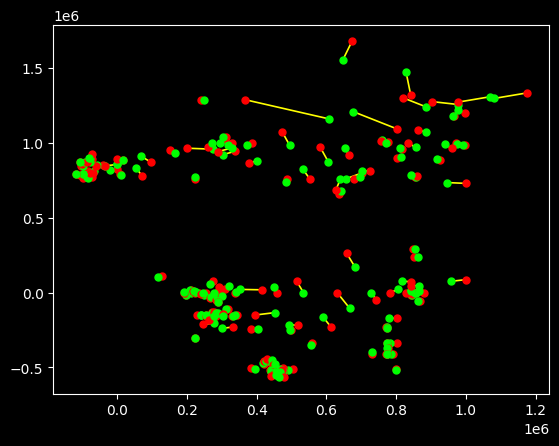

In [23]:
# Dictionaries to track void triangles and their properties
void_triangles = {}  # Maps void IDs to triangle data
tri_to_void_id = {}  # Maps triangles to their void IDs

# Process edges shared by two triangles
for edge, tris in edge_to_triangles.items():
    # Skip edges not shared by exactly two triangles or without tangency data
    if len(tris) != 2 or edge not in edge_to_tangency:
        continue

    tangency_info = edge_to_tangency[edge]
    # Skip if we don't have exactly two tangency points (one per triangle)
    if len(tangency_info) != 2:
        continue

    # Unpack the tangency information
    (tri_a, tg_a), (tri_b, tg_b) = tangency_info

    # Process both vertices of the edge
    for vertex in edge:
        pt_vertex = points[vertex]  # Current vertex coordinates
        
        # Calculate distances to both tangency points
        d_a = np.linalg.norm(pt_vertex - tg_a)
        d_b = np.linalg.norm(pt_vertex - tg_b)

        # Determine which tangency point is closer
        if d_a < d_b:
            closest_tg = tg_a
            source_tri = tri_a
            target_tri = tri_b
        else:
            closest_tg = tg_b
            source_tri = tri_b
            target_tri = tri_a

        # Get vertices of the target triangle
        target_verts = list(target_tri)

        # Find candidate edges that connect to our vertex
        candidate_edges = [
            tuple(sorted([vertex, v]))
            for v in target_verts if v != vertex
        ]
        # Exclude the current edge
        valid_edges = [e for e in candidate_edges if e != edge]
        
        # We expect exactly one valid edge (the other edge of the triangle)
        if len(valid_edges) != 1:
            continue

        correct_edge = valid_edges[0]
        # Get the other vertex of this edge
        v_other = correct_edge[0] if correct_edge[1] == vertex else correct_edge[1]

        # Prepare for projection
        a = points[vertex].astype(float)  # Current vertex
        b = points[v_other].astype(float)  # Connected vertex
        dir_vec = b - a  # Direction vector
        norm = np.linalg.norm(dir_vec)
        if norm == 0:  # Skip if points coincide
            continue
        dir_vec /= norm  # Normalize direction vector

        # Project the tangency point onto the adjacent edge
        dist = np.linalg.norm(pt_vertex - closest_tg)
        proj_point = a + dist * dir_vec

        # Visualization of the projection
        # Yellow line from tangency point to projected point
        plt.plot([closest_tg[0], proj_point[0]], [closest_tg[1], proj_point[1]], 
                color='yellow', linewidth=1.2, zorder=7)
        
        # Red point at the projected location
        plt.scatter(proj_point[0], proj_point[1], color='red', s=25, zorder=8)
        
        # Green point at the tangency point (start of projection)
        plt.scatter(closest_tg[0], closest_tg[1], color='lime', s=25, zorder=8)

        # Associate the projected point with its void triangle
        rounded_proj = tuple(np.round(proj_point, decimals=6))  # Avoid floating point issues
        sorted_target_tri = tuple(sorted(target_tri))

        # Create new void triangle entry if needed
        if sorted_target_tri not in tri_to_void_id:
            void_id = len(void_triangles) + 1
            tri_to_void_id[sorted_target_tri] = void_id
            void_triangles[void_id] = {
                "triangle": sorted_target_tri,
                "points": []
            }

        # Add this projected point to the void triangle
        void_id = tri_to_void_id[sorted_target_tri]
        void_triangles[void_id]["points"].append(rounded_proj)

### 8. Output and Final Visualization

In this final section, we:

- Print detailed information about all detected void triangles and their associated projected points.
- Finalize the matplotlib visualization by adding a title, setting an equal aspect ratio, enabling the legend, and displaying the plot.
- This visualization includes the triangulation, incenters, tangency points, and projected lines that represent void areas within the triangulation.

Void_Triangle 1 (verts: (9, 10, 11)):
  🔴 Point: (230091.0, -151253.593588)
Void_Triangle 2 (verts: (8, 9, 11)):
  🔴 Point: (253598.504929, -150729.384151)
  🔴 Point: (271045.872842, -133399.0)
Void_Triangle 3 (verts: (8, 11, 14)):
  🔴 Point: (255573.354202, -156669.0)
  🔴 Point: (284890.982994, -156669.0)
  🔴 Point: (304833.846271, -144949.524238)
Void_Triangle 4 (verts: (1, 2, 3)):
  🔴 Point: (196296.0, -14843.583092)
Void_Triangle 5 (verts: (1, 3, 4)):
  🔴 Point: (224718.0, -303774.416908)
  🔴 Point: (196769.862851, -5312.125605)
Void_Triangle 6 (verts: (1, 4, 79)):
  🔴 Point: (215895.201163, 10321.415911)
  🔴 Point: (223789.034421, 0.0)
  🔴 Point: (128225.137804, 112882.882355)
Void_Triangle 7 (verts: (4, 5, 79)):
  🔴 Point: (212569.482148, 20019.021975)
  🔴 Point: (217217.60632, 8774.390542)
Void_Triangle 8 (verts: (0, 1, 79)):
  🔴 Point: (190962.781043, 0.0)
Void_Triangle 9 (verts: (57, 66, 67)):
  🔴 Point: (-39714.43054, 852939.543425)
  🔴 Point: (-59519.514118, 842844.991925)
V

C:\Users\T470\AppData\Local\Temp\ipykernel_41844\3289082975.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()  # Show the legend


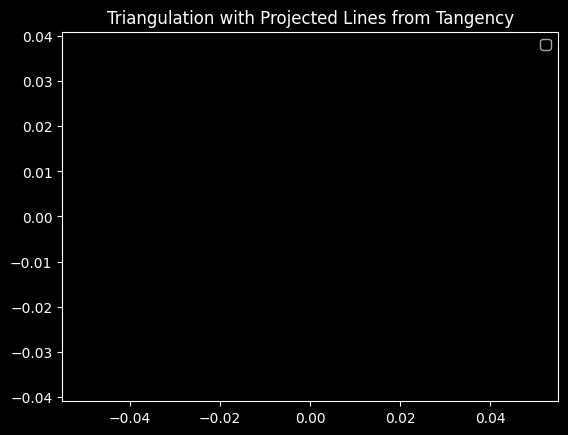

In [29]:
# Print information about all void triangles
for void_id, data in void_triangles.items():
    print(f"Void_Triangle {void_id} (verts: {data['triangle']}):")
    for pt in data["points"]:
        print(f"  🔴 Point: {pt}")

# Finalize the visualization
plt.title('Triangulation with Projected Lines from Tangency')
plt.axis('equal')  # Ensure proper aspect ratio
plt.legend()  # Show the legend
plt.show()  # Display the plot